In [1]:
from google.colab import files

uploaded = files.upload()

Saving stroke_prediction_dataset.csv to stroke_prediction_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [3]:
import pandas as pd

df = pd.read_csv("stroke_prediction_dataset.csv")

df.head()

,Patient ID,Patient Name,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,...,Alcohol Intake,Physical Activity,Stroke History,Family History of Stroke,Dietary Habits,Stress Levels,Blood Pressure Levels,Cholesterol Levels,Symptoms,Diagnosis
0,18153,Mamooty Khurana,56,Male,0,1,Married,Self-employed,Rural,130.91,...,Social Drinker,Moderate,0,Yes,Vegan,3.48,140/108,"HDL: 68, LDL: 133","Difficulty Speaking, Headache",Stroke
1,62749,Kaira Subramaniam,80,Male,0,0,Single,Self-employed,Urban,183.73,...,Never,Low,0,No,Paleo,1.73,146/91,"HDL: 63, LDL: 70","Loss of Balance, Headache, Dizziness, Confusion",Stroke
2,32145,Dhanush Balan,26,Male,1,1,Married,Never Worked,Rural,189.00,...,Rarely,High,0,Yes,Paleo,7.31,154/97,"HDL: 59, LDL: 95","Seizures, Dizziness",Stroke
3,6154,Ivana Baral,73,Male,0,0,Married,Never Worked,Urban,185.29,...,Frequent Drinker,Moderate,0,No,Paleo,5.35,174/81,"HDL: 70, LDL: 137","Seizures, Blurred Vision, Severe Fatigue, Head...",No Stroke
4,48973,Darshit Jayaraman,51,Male,1,1,Divorced,Self-employed,Urban,177.34,...,Rarely,Low,0,Yes,Pescatarian,6.84,121/95,"HDL: 65, LDL: 68",Difficulty Speaking,Stroke


In [4]:
df.shape

(15000, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient ID                15000 non-null  int64  
 1   Patient Name              15000 non-null  object 
 2   Age                       15000 non-null  int64  
 3   Gender                    15000 non-null  object 
 4   Hypertension              15000 non-null  int64  
 5   Heart Disease             15000 non-null  int64  
 6   Marital Status            15000 non-null  object 
 7   Work Type                 15000 non-null  object 
 8   Residence Type            15000 non-null  object 
 9   Average Glucose Level     15000 non-null  float64
 10  Body Mass Index (BMI)     15000 non-null  float64
 11  Smoking Status            15000 non-null  object 
 12  Alcohol Intake            15000 non-null  object 
 13  Physical Activity         15000 non-null  object 
 14  Stroke

## Member 3 - Outlier Detection and Analysis

### Introduction

Outliers are observations that differ significantly from other observations in a dataset.

Outlier analysis was performed on the following numerical attributes:

- Age
- Body Mass Index (BMI)
- Average Glucose Level
- Stress Levels

Boxplots were used for visual inspection, while the Interquartile Range (IQR) method was used for numerical outlier detection.

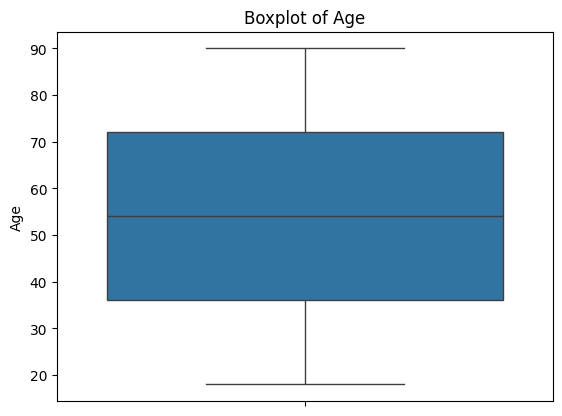

In [6]:
sns.boxplot(y=df['Age'])

plt.title("Boxplot of Age")

plt.show()

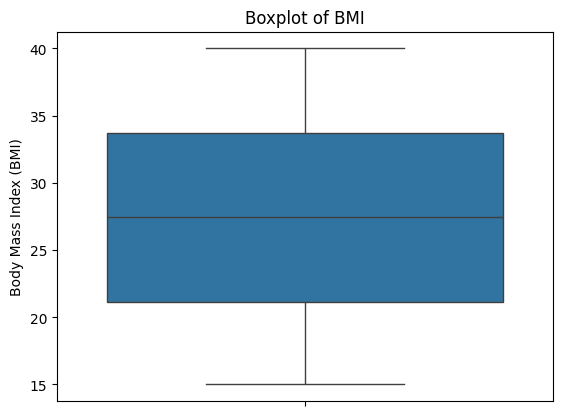

In [7]:
sns.boxplot(y=df['Body Mass Index (BMI)'])

plt.title("Boxplot of BMI")

plt.show()

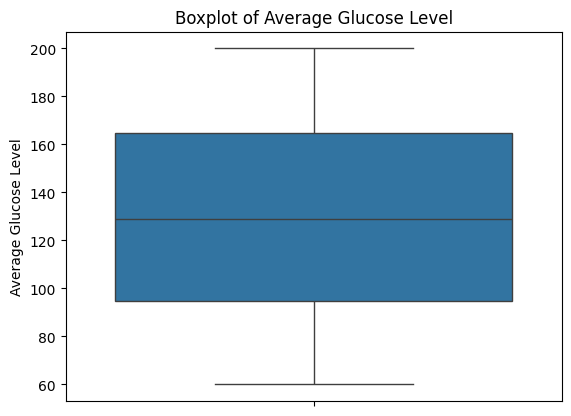

In [8]:
sns.boxplot(y=df['Average Glucose Level'])

plt.title("Boxplot of Average Glucose Level")

plt.show()

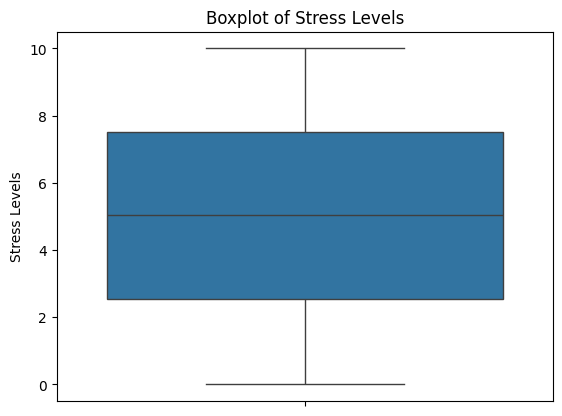

In [9]:
sns.boxplot(y=df['Stress Levels'])

plt.title("Boxplot of Stress Levels")

plt.show()

In [10]:
Q1 = df['Average Glucose Level'].quantile(0.25)

Q3 = df['Average Glucose Level'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 94.5175
Q3 = 164.5925
IQR = 70.075


In [11]:
lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Lower Bound = -10.595000000000013
Upper Bound = 269.70500000000004


In [12]:
outliers = df[
    (df['Average Glucose Level'] < lower_bound) |
    (df['Average Glucose Level'] > upper_bound)
]

print("Number of Outliers =", len(outliers))

Number of Outliers = 0


In [13]:
Q1 = df['Body Mass Index (BMI)'].quantile(0.25)
Q3 = df['Body Mass Index (BMI)'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Body Mass Index (BMI)'] < lower_bound) |
    (df['Body Mass Index (BMI)'] > upper_bound)
]

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)
print("Number of Outliers =", len(outliers))

Q1 = 21.16
Q3 = 33.72
IQR = 12.559999999999999
Lower Bound = 2.320000000000004
Upper Bound = 52.559999999999995
Number of Outliers = 0


In [14]:
Q1 = df['Average Glucose Level'].quantile(0.25)
Q3 = df['Average Glucose Level'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Average Glucose Level'] < lower_bound) |
    (df['Average Glucose Level'] > upper_bound)
]

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)
print("Number of Outliers =", len(outliers))

Q1 = 94.5175
Q3 = 164.5925
IQR = 70.075
Lower Bound = -10.595000000000013
Upper Bound = 269.70500000000004
Number of Outliers = 0


In [15]:
Q1 = df['Stress Levels'].quantile(0.25)
Q3 = df['Stress Levels'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Stress Levels'] < lower_bound) |
    (df['Stress Levels'] > upper_bound)
]

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)
print("Number of Outliers =", len(outliers))

Q1 = 2.54
Q3 = 7.52
IQR = 4.9799999999999995
Lower Bound = -4.929999999999999
Upper Bound = 14.989999999999998
Number of Outliers = 0


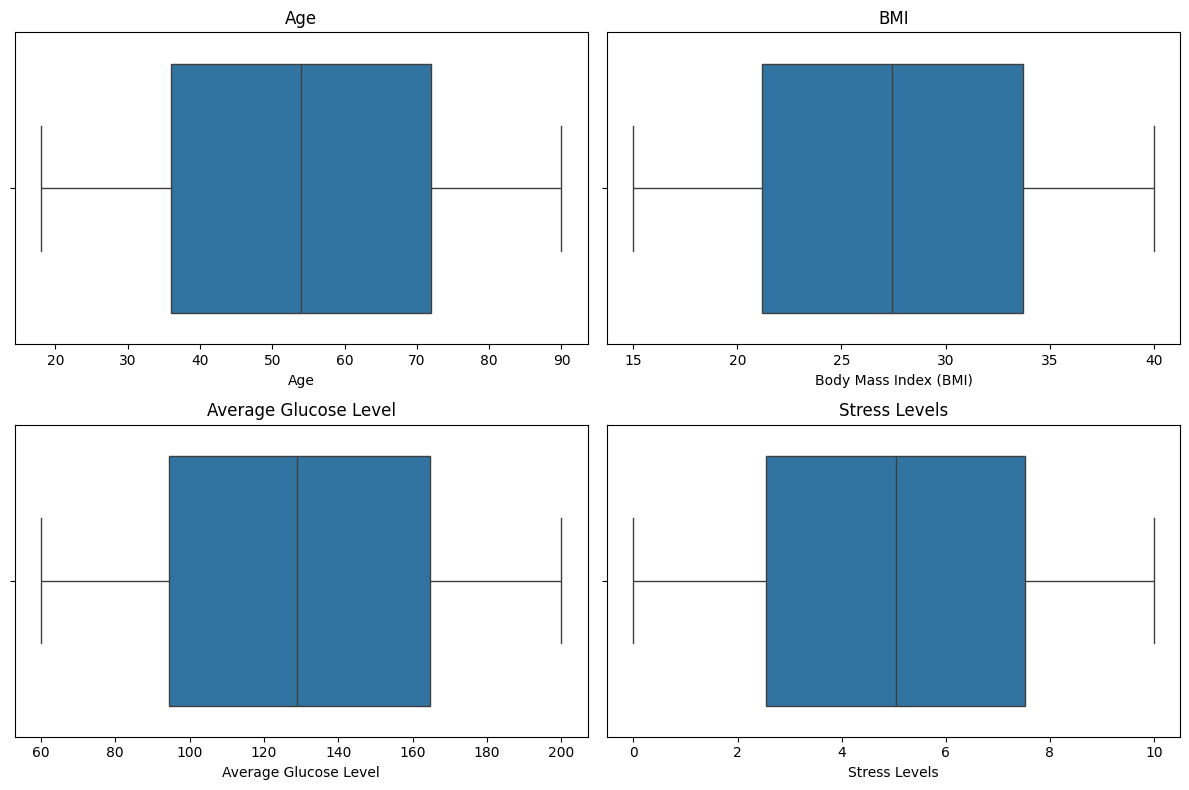

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

# Age
plt.subplot(2,2,1)
sns.boxplot(x=df['Age'])
plt.title('Age')

# BMI
plt.subplot(2,2,2)
sns.boxplot(x=df['Body Mass Index (BMI)'])
plt.title('BMI')

# Average Glucose Level
plt.subplot(2,2,3)
sns.boxplot(x=df['Average Glucose Level'])
plt.title('Average Glucose Level')

# Stress Levels
plt.subplot(2,2,4)
sns.boxplot(x=df['Stress Levels'])
plt.title('Stress Levels')

plt.tight_layout()
plt.show()

## Conclusion

Outlier detection was successfully performed using boxplots and the Interquartile Range (IQR) method.

The analysis indicated that no significant outliers were present in the dataset. Therefore, no additional outlier treatment was required before further preprocessing.